# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

p = 0.92

For X = 1:

P(X = 1) = p
         = 0.92

For X = 0:

P(X = 0) = 1 - p
         = 1 - 0.92
         = 0.08


(b) Mean:

E[X] = p
     = 0.92


Variance:

Var(X) = p(1 - p)
       = 0.92(1 - 0.92)
       = 0.92 × 0.08
       = 0.0736

(a) Probabilities
P(X = 1) = 0.9200
P(X = 0) = 0.0800

(b) Mean and Variance
Mean = 0.9200
Variance = 0.0736

(c) SciPy Check
Mean from SciPy = 0.9200
Variance from SciPy = 0.0736


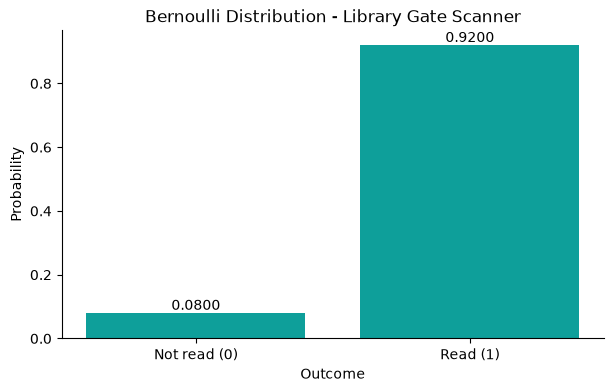

In [2]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
# Q1 — Bernoulli Distribution: Library Gate Scanner

# Given
p = 0.92

# (a) Probabilities
P_X1 = p
P_X0 = 1 - p

print("(a) Probabilities")
print("P(X = 1) =", f"{P_X1:.4f}")
print("P(X = 0) =", f"{P_X0:.4f}")

# (b) Mean and Variance
mean = p
variance = p * (1 - p)

print("\n(b) Mean and Variance")
print("Mean =", f"{mean:.4f}")
print("Variance =", f"{variance:.4f}")

# (c) PMF and Plot
x = [0, 1]
pmf = stats.bernoulli.pmf(x, p)

plt.bar(x, pmf, color=DISCRETE_COLOR)

plt.xticks(x, ["Not read (0)", "Read (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution - Library Gate Scanner")

# Probability values on bars
for i, prob in zip(x, pmf):
    plt.text(i, prob + 0.01, f"{prob:.4f}", ha="center")

# Check mean and variance using scipy
print("\n(c) SciPy Check")
print("Mean from SciPy =", f"{stats.bernoulli.mean(p):.4f}")
print("Variance from SciPy =", f"{stats.bernoulli.var(p):.4f}")

plt.show()

# ------------------------------------------------------------

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

Total scans = 2000
Accepted scans = 1740

Estimated p = Accepted scans / Total scans
            = 1740 / 2000
            = 0.87

Therefore,

P(X = 1) = p
         = 0.87

P(X = 0) = 1 - p
         = 1 - 0.87
         = 0.13

The full PMF is:

P(X = x) = p^x(1-p)^(1-x)

Substituting p = 0.87,

P(X = x) = (0.87)^x(0.13)^(1-x)


(b) Mean:

E[X] = p
     = 0.87


Variance:

Var(X) = p(1-p)
       = 0.87(1-0.87)
       = 0.87 × 0.13
       = 0.1131


For a Bernoulli variable, the variance is largest when:

p = 0.5

Maximum variance:

Var(X) = 0.5(1-0.5)
       = 0.5 × 0.5
       = 0.25

Therefore, the largest possible variance is 0.25.

(a) Estimated p and PMF
Estimated p = 0.8700
P(X = 1) = 0.8700
P(X = 0) = 0.1300

PMF:
P(X = x) = p^x (1-p)^(1-x)
Using p = 0.8700:
P(X = x) = (0.8700)^x (0.1300)^(1-x)

(b) Mean and Variance
Mean = 0.8700
Variance = 0.1131

Maximum possible variance
Variance is largest when p = 0.5
Maximum variance = 0.2500

(c) Simulation
Theoretical p = 0.8700
Simulated proportion = 0.8675


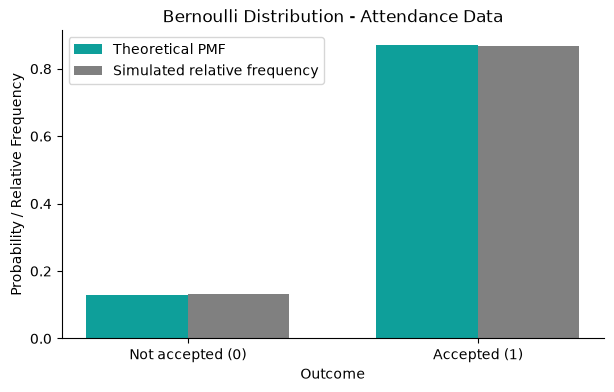

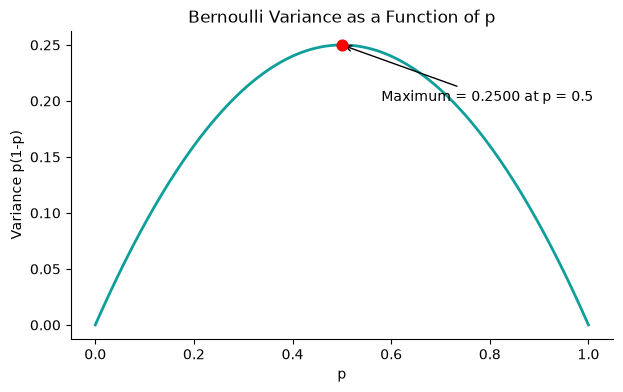

In [3]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
# Q2 — Bernoulli Distribution: Estimating p from Attendance Data

# Given
total_scans = 2000
accepted = 1740

# (a) Estimate p and PMF
p = accepted / total_scans

P_X1 = p
P_X0 = 1 - p

print("(a) Estimated p and PMF")
print("Estimated p =", f"{p:.4f}")
print("P(X = 1) =", f"{P_X1:.4f}")
print("P(X = 0) =", f"{P_X0:.4f}")

print("\nPMF:")
print("P(X = x) = p^x (1-p)^(1-x)")
print(f"Using p = {p:.4f}:")
print(f"P(X = x) = ({p:.4f})^x ({1-p:.4f})^(1-x)")

# (b) Mean and variance
mean = p
variance = p * (1 - p)

print("\n(b) Mean and Variance")
print("Mean =", f"{mean:.4f}")
print("Variance =", f"{variance:.4f}")

# Maximum possible variance
p_max = 0.5
max_variance = p_max * (1 - p_max)

print("\nMaximum possible variance")
print("Variance is largest when p = 0.5")
print("Maximum variance =", f"{max_variance:.4f}")

# (c) Simulate 2000 Bernoulli trials
simulated = stats.bernoulli.rvs(
    p,
    size=total_scans,
    random_state=42
)

simulated_proportion = simulated.mean()

print("\n(c) Simulation")
print("Theoretical p =", f"{p:.4f}")
print("Simulated proportion =", f"{simulated_proportion:.4f}")

# Theoretical PMF
x = [0, 1]
theoretical_pmf = stats.bernoulli.pmf(x, p)

# Simulated relative frequencies
simulated_freq = [
    np.mean(simulated == 0),
    np.mean(simulated == 1)
]

# Grouped bar chart
width = 0.35

plt.figure()

plt.bar(
    np.array(x) - width/2,
    theoretical_pmf,
    width,
    color=DISCRETE_COLOR,
    label="Theoretical PMF"
)

plt.bar(
    np.array(x) + width/2,
    simulated_freq,
    width,
    color="gray",
    label="Simulated relative frequency"
)

plt.xticks(x, ["Not accepted (0)", "Accepted (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability / Relative Frequency")
plt.title("Bernoulli Distribution - Attendance Data")
plt.legend()

plt.show()

# Variance against p
p_values = np.linspace(0, 1, 200)
variance_values = p_values * (1 - p_values)

plt.figure()

plt.plot(
    p_values,
    variance_values,
    color=DISCRETE_COLOR,
    lw=2
)

plt.scatter(
    p_max,
    max_variance,
    color="red",
    s=60,
    zorder=5
)

plt.annotate(
    f"Maximum = {max_variance:.4f} at p = {p_max}",
    xy=(p_max, max_variance),
    xytext=(0.58, 0.20),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("p")
plt.ylabel("Variance p(1-p)")
plt.title("Bernoulli Variance as a Function of p")

plt.show()

# ------------------------------------------------------------

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

Number of questions, n = 12

Each question has 4 options and only 1 is correct.

Therefore,

p = 1/4 = 0.25

1 - p = 1 - 0.25 = 0.75

BINS conditions:

Binary: Each answer is correct or incorrect.
Independent: Each guess is independent of the others.
Number of trials: n = 12 is fixed.
Same probability: p = 0.25 for every question.

Therefore, the BINS conditions hold.

For X = 5:

P(X = 5) = C(12,5)(0.25)^5(0.75)^7

C(12,5) = 12! / (5! × 7!)
        = 792

Therefore,

P(X = 5) = 792(0.25)^5(0.75)^7
         = 0.1032


(b) Mean:

E[X] = np
     = 12(0.25)
     = 3


Variance:

Var(X) = np(1-p)
       = 12(0.25)(0.75)
       = 2.25

(a) Probability
n = 12
p = 0.2500
P(X = 5) = 0.1032
C(12,5) = 792
Hand calculation = 0.1032

(b) Mean and Variance
Mean = 3.0000
Variance = 2.2500


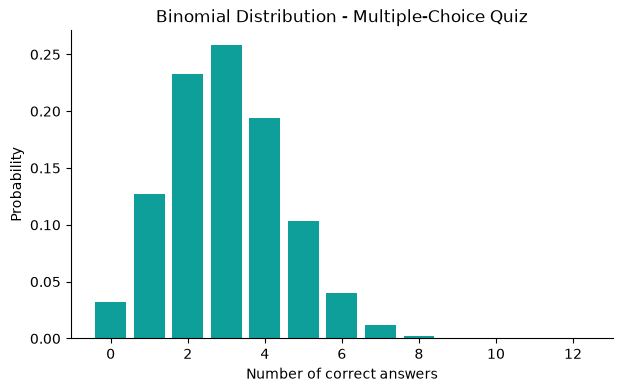

In [4]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------

# Q3 — Binomial Distribution: Guessing a Multiple-Choice Quiz

# Given
n = 12
p = 1 / 4

# (a) Probability of exactly 5 correct answers
k_value = 5

prob_5 = stats.binom.pmf(k_value, n, p)

print("(a) Probability")
print("n =", n)
print("p =", f"{p:.4f}")
print("P(X = 5) =", f"{prob_5:.4f}")

# Check the hand calculation
combination = comb(n, k_value)

hand_probability = (
    combination
    * (p ** k_value)
    * ((1 - p) ** (n - k_value))
)

print("C(12,5) =", combination)
print("Hand calculation =", f"{hand_probability:.4f}")

# (b) Mean and variance
mean = stats.binom.mean(n, p)
variance = stats.binom.var(n, p)

print("\n(b) Mean and Variance")
print("Mean =", f"{mean:.4f}")
print("Variance =", f"{variance:.4f}")

# (c) PMF plot for k = 0 to 12
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)

plt.bar(k, pmf, color=DISCRETE_COLOR)

plt.xlabel("Number of correct answers")
plt.ylabel("Probability")
plt.title("Binomial Distribution - Multiple-Choice Quiz")

plt.show()

# ------------------------------------------------------------

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

λ = 3 emails per hour

The Poisson formula is:

P(X = k) = (λ^k e^(-λ)) / k!


For X = 0:

P(X = 0) = (3^0 e^(-3)) / 0!
         = (1)(0.0498) / 1
         = 0.0498


For X = 2:

P(X = 2) = (3^2 e^(-3)) / 2!
         = (9)(0.0498) / 2
         = 0.2240


(b) Mean:

E[X] = λ
     = 3


Variance:

Var(X) = λ
       = 3


The special property of the Poisson distribution is that
the mean and variance are equal.

(a) Probabilities
P(X = 0) = 0.0498
P(X = 2) = 0.2240

(b) Mean and Variance
Mean = 3.0000
Variance = 3.0000
Mean = Variance, which is a special property of the Poisson distribution.


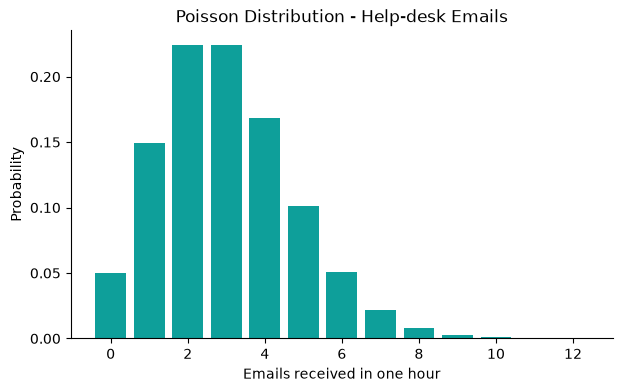


Additional probabilities
P(X = 0) = 0.0498
P(X = 2) = 0.2240
P(X <= 5) = 0.9161
Smallest k for P(X <= k) >= 0.95 = 6
P(X <= k) = 0.9665


In [5]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
# Q5 — Poisson Distribution: Help-desk Emails

# Given
la = 3

# (a) P(X = 0) and P(X = 2)
P_X0 = stats.poisson.pmf(0, la)
P_X2 = stats.poisson.pmf(2, la)

print("(a) Probabilities")
print("P(X = 0) =", f"{P_X0:.4f}")
print("P(X = 2) =", f"{P_X2:.4f}")

# (b) Mean and variance
mean = stats.poisson.mean(la)
variance = stats.poisson.var(la)

print("\n(b) Mean and Variance")
print("Mean =", f"{mean:.4f}")
print("Variance =", f"{variance:.4f}")
print("Mean = Variance, which is a special property of the Poisson distribution.")

# (c) PMF for k = 0 to 12
k = np.arange(0, 13)
pmf = stats.poisson.pmf(k, la)

plt.bar(k, pmf, color=DISCRETE_COLOR)

plt.xlabel("Emails received in one hour")
plt.ylabel("Probability")
plt.title("Poisson Distribution - Help-desk Emails")

plt.show()

# Additional probabilities
P_X_le_5 = stats.poisson.cdf(5, la)

print("\nAdditional probabilities")
print("P(X = 0) =", f"{P_X0:.4f}")
print("P(X = 2) =", f"{P_X2:.4f}")
print("P(X <= 5) =", f"{P_X_le_5:.4f}")

# Smallest k for which P(X <= k) >= 0.95
k_95 = stats.poisson.ppf(0.95, la)

print("Smallest k for P(X <= k) >= 0.95 =", int(k_95))
print(
    "P(X <= k) =",
    f"{stats.poisson.cdf(int(k_95), la):.4f}"
)


# ------------------------------------------------------------

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

Average error rate = 1.5 errors per hour
Time = 8 hours

Therefore,

λ = 1.5 × 8
  = 12 errors per 8-hour shift


For a clean shift, X = 0.

Using the Poisson formula:

P(X = k) = (λ^k e^(-λ)) / k!

P(X = 0) = (12^0 e^(-12)) / 0!
         = (1)(e^(-12)) / 1
         = e^(-12)
         ≈ 0.000006
         ≈ 0.0000


(b) Mean:

E[X] = λ
     = 12


Variance:

Var(X) = λ
       = 12


(d) Probability of more than 18 errors:

P(X > 18) = 1 - P(X ≤ 18)

Therefore,

P(X > 18) = 1 - P(X ≤ 18)

In Python, the scipy function used directly is:

stats.poisson.sf(18, 12)

P(X > 18) ≈ 0.0374

(a) Whole-shift lambda and clean-shift probability
Lambda for 1 hour = 1.5000
Lambda for 8 hours = 12.0000
P(X = 0) = 0.0000

(b) Mean and Variance
Mean = 12.0000
Variance = 12.0000

(d) Probability of more than 18 errors
P(X > 18) = 0.0374


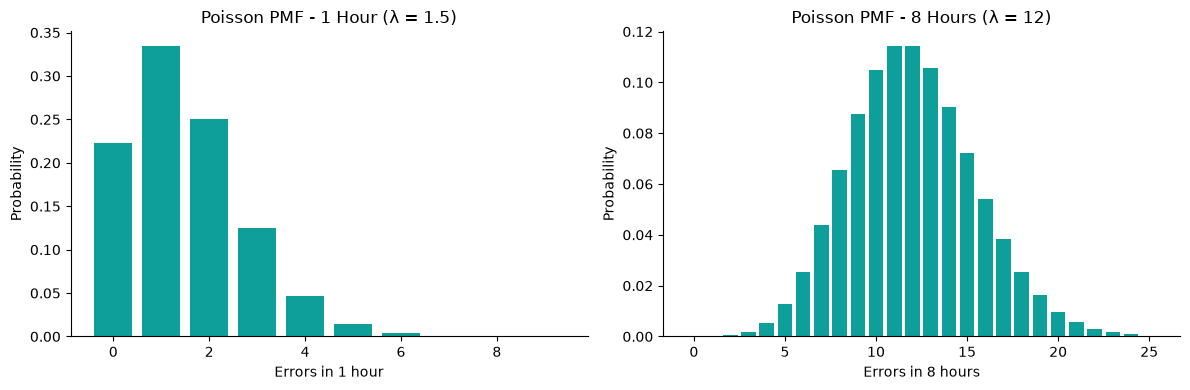

In [6]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------

# Q6 — Poisson Distribution: Server Errors over a Night Shift

# Given
rate_per_hour = 1.5
hours = 8

# (a) Lambda for the whole 8-hour shift
la_1hour = rate_per_hour
la_8hour = rate_per_hour * hours

# Clean shift: X = 0
P_X0 = stats.poisson.pmf(0, la_8hour)

print("(a) Whole-shift lambda and clean-shift probability")
print("Lambda for 1 hour =", f"{la_1hour:.4f}")
print("Lambda for 8 hours =", f"{la_8hour:.4f}")
print("P(X = 0) =", f"{P_X0:.4f}")

# (b) Mean and variance
mean = stats.poisson.mean(la_8hour)
variance = stats.poisson.var(la_8hour)

print("\n(b) Mean and Variance")
print("Mean =", f"{mean:.4f}")
print("Variance =", f"{variance:.4f}")

# (d) Probability of more than 18 errors
P_more_18 = stats.poisson.sf(18, la_8hour)

print("\n(d) Probability of more than 18 errors")
print("P(X > 18) =", f"{P_more_18:.4f}")

# (c) PMF plots for 1-hour and 8-hour windows
k_1hour = np.arange(0, 10)
pmf_1hour = stats.poisson.pmf(k_1hour, la_1hour)

k_8hour = np.arange(0, 26)
pmf_8hour = stats.poisson.pmf(k_8hour, la_8hour)

plt.figure(figsize=(12, 4))

# 1-hour window
plt.subplot(1, 2, 1)
plt.bar(k_1hour, pmf_1hour, color=DISCRETE_COLOR)
plt.xlabel("Errors in 1 hour")
plt.ylabel("Probability")
plt.title("Poisson PMF - 1 Hour (λ = 1.5)")

# 8-hour window
plt.subplot(1, 2, 2)
plt.bar(k_8hour, pmf_8hour, color=DISCRETE_COLOR)
plt.xlabel("Errors in 8 hours")
plt.ylabel("Probability")
plt.title("Poisson PMF - 8 Hours (λ = 12)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

Mean, μ = 18 hours

Standard deviation, σ = 1.5 hours

For a battery life of 15 hours:

Z = (X - μ) / σ

  = (15 - 18) / 1.5

  = -3 / 1.5

  = -2

Therefore, the Z-score is -2.

This means that a battery life of 15 hours is 2 standard
deviations below the mean.


(b) Using the 68–95–99.7 rule,

About 95% of the values lie within:

μ ± 2σ

= 18 ± 2(1.5)

= 18 ± 3

Therefore,

Lower limit = 15 hours
Upper limit = 21 hours

So, about 95% of the phones have battery lives between
15 hours and 21 hours.

(a) Z-score
Z = -2.0000
The battery life of 15 hours is 2 standard deviations below the mean.

(b) 95% Interval
Lower limit = 15.00 hours
Upper limit = 21.00 hours


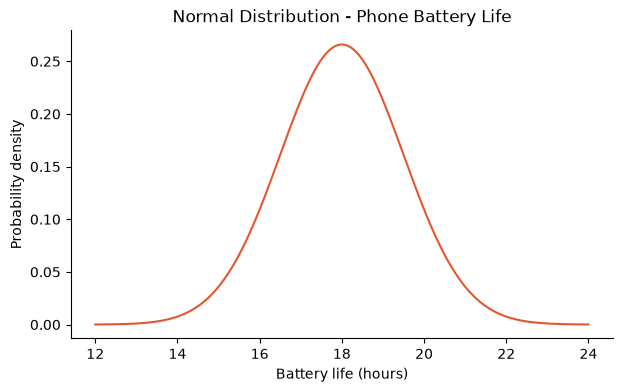

In [7]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
# Q7 — Normal Distribution: Battery Life of a Phone

# Given
mu = 18
sigma = 1.5

# (a) Z-score for 15 hours
x_value = 15

z = (x_value - mu) / sigma

print("(a) Z-score")
print("Z =", f"{z:.4f}")
print("The battery life of 15 hours is 2 standard deviations below the mean.")

# (b) About 95% interval using 68–95–99.7 rule
lower = mu - 2 * sigma
upper = mu + 2 * sigma

print("\n(b) 95% Interval")
print("Lower limit =", f"{lower:.2f}", "hours")
print("Upper limit =", f"{upper:.2f}", "hours")

# (c) Generate 400 equally spaced values over μ ± 4σ
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)

# Calculate PDF
pdf = stats.norm.pdf(x, mu, sigma)

# Plot
plt.plot(x, pdf, color=CONTINUOUS_COLOR)

plt.xlabel("Battery life (hours)")
plt.ylabel("Probability density")
plt.title("Normal Distribution - Phone Battery Life")

plt.show()
# ------------------------------------------------------------

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

Mean, μ = 200 ml

P(X > 210) = 0.025

Therefore,

P(X ≤ 210) = 1 - 0.025
            = 0.975

Given,

z₀.₉₇₅ ≈ 1.96

Using the Z-score formula:

Z = (X - μ) / σ

1.96 = (210 - 200) / σ

1.96 = 10 / σ

Therefore,

σ = 10 / 1.96
  ≈ 5.1020 ml


(b) We need the volume below which only 1% of cups fall.

Therefore,

P(X < x) = 0.01

The standard normal value is:

z₀.₀₁ ≈ -2.3263

Using:

z = (x - μ) / σ

-2.3263 = (x - 200) / 5.1020

x - 200 = -2.3263 × 5.1020

x - 200 ≈ -11.872

Therefore,

x ≈ 188.128 ml

So, approximately 188.13 ml is the volume below which only 1% of cups fall.

The scipy function used is:

stats.norm.ppf(0.01)

(a) Standard Deviation
z_0.975 = 1.9600
Standard deviation = 5.1021 ml

(b) 1% Volume Cutoff
z_0.01 = -2.3263
Volume = 188.1307 ml
Scipy expression: stats.norm.ppf(0.01)


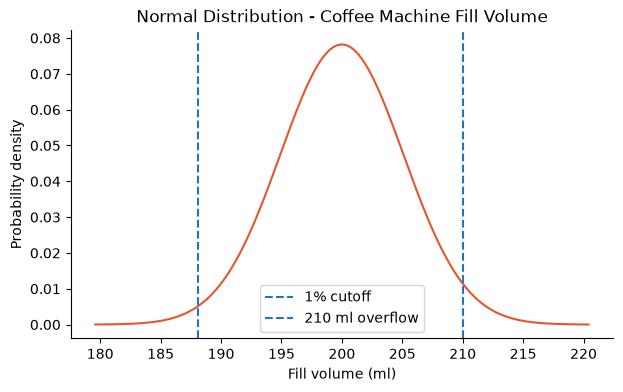

In [8]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------

# Q8 — Normal Distribution: Calibrating a Coffee Machine

# Given
mu = 200
overflow_volume = 210
overflow_probability = 0.025

# (a) Compute sigma using the exact standard normal value
z_975 = stats.norm.ppf(0.975)

sigma = (overflow_volume - mu) / z_975

print("(a) Standard Deviation")
print("z_0.975 =", f"{z_975:.4f}")
print("Standard deviation =", f"{sigma:.4f}", "ml")

# (b) Volume below which only 1% of cups fall
z_01 = stats.norm.ppf(0.01)

volume_1_percent = mu + z_01 * sigma

print("\n(b) 1% Volume Cutoff")
print("z_0.01 =", f"{z_01:.4f}")
print("Volume =", f"{volume_1_percent:.4f}", "ml")

print("Scipy expression: stats.norm.ppf(0.01)")

# (c) Plot the PDF
x = np.linspace(
    mu - 4 * sigma,
    mu + 4 * sigma,
    400
)

pdf = stats.norm.pdf(x, mu, sigma)

plt.plot(
    x,
    pdf,
    color=CONTINUOUS_COLOR
)

plt.axvline(
    volume_1_percent,
    linestyle="--",
    label="1% cutoff"
)

plt.axvline(
    overflow_volume,
    linestyle="--",
    label="210 ml overflow"
)

plt.xlabel("Fill volume (ml)")
plt.ylabel("Probability density")
plt.title("Normal Distribution - Coffee Machine Fill Volume")
plt.legend()

plt.show()

# ------------------------------------------------------------

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [ ]:
(a) Given,

Lower limit, a = 0 minutes

Upper limit, b = 15 minutes


Mean:

E[X] = (a + b) / 2

     = (0 + 15) / 2

     = 15 / 2

     = 7.5 minutes


Variance:

Var(X) = (b - a)^2 / 12

       = (15 - 0)^2 / 12

       = 15^2 / 12

       = 225 / 12

       = 18.75 minutes²


Therefore,

Mean waiting time = 7.5 minutes

Variance = 18.75 minutes²

(a) Mean and Variance
Mean = 7.5000 minutes
Variance = 18.7500 minutes²


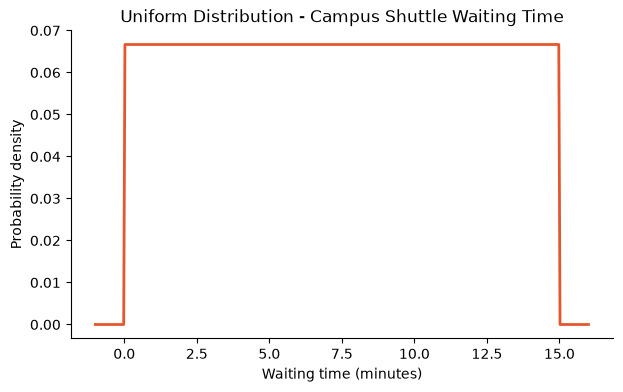

In [9]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------

# Q9 — Uniform Distribution: Waiting for the Campus Shuttle

# Given
a = 0
b = 15

# (a) Mean
mean = (a + b) / 2

# Variance
variance = (b - a) ** 2 / 12

print("(a) Mean and Variance")
print("Mean =", f"{mean:.4f}", "minutes")
print("Variance =", f"{variance:.4f}", "minutes²")

# (b) PDF
x = np.linspace(a - 1, b + 1, 400)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)

# Plot
plt.plot(
    x,
    pdf,
    color=CONTINUOUS_COLOR,
    lw=2
)

plt.xlabel("Waiting time (minutes)")
plt.ylabel("Probability density")
plt.title("Uniform Distribution - Campus Shuttle Waiting Time")

plt.show()
# ------------------------------------------------------------